In [ ]:
import sys
from pathlib import Path

# Ensure repo root is on the path so anp_emulator and train_anp_emulator are importable
sys.path.insert(0, str(Path('..').resolve()))


In [1]:
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from anp_emulator import Emulator
from train_anp_emulator import build_tasks, split_tasks, resolve_profile_file

In [3]:
RUN_DIR = Path('anp_training_runs/anp_all_profiles_20260331_203537')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

if not RUN_DIR.exists():
    raise FileNotFoundError(f'Run directory not found: {RUN_DIR}')

emu = Emulator.from_run_dir(RUN_DIR, device=DEVICE)
print('Loaded:', RUN_DIR)
print('Available fields:', emu.available_fields())

Loaded: anp_training_runs/anp_all_profiles_20260331_203537
Available fields: ['gas_density', 'temperature', 'pressure', 'metallicity']


In [4]:
oneP_param_csv = Path('/mnt/home/mlee1/Sims/IllustrisTNG/L50n512/1P/CosmoAstroSeed_IllustrisTNG_L50n512_1P.txt')
oneP_theta_df = pd.read_csv(oneP_param_csv, sep=r'\s+', engine='python')
oneP_theta_df = oneP_theta_df.rename(columns={'#Name': 'tag'})
fiducial_params = oneP_theta_df[oneP_theta_df['tag'] == '1P_p1_0'].iloc[0, 1:-1].to_numpy()

In [5]:
# 1P setup on external test profile directory.
import re

ONEP_TEST_PROFILE_DIR = Path('/mnt/home/mlee1/ceph/Profiles_cy_test')
ONEP_PARAM_CSV = Path('/mnt/home/mlee1/Sims/IllustrisTNG/L50n512/1P/CosmoAstroSeed_IllustrisTNG_L50n512_1P.txt')
ONEP_REQUESTED_FIELDS = ['pressure', 'temperature', 'gas_density', 'metallicity']
ONEP_NSAMPLES = 30
ONEP_MASS_CUT = 1e12

if not ONEP_TEST_PROFILE_DIR.exists():
    raise FileNotFoundError(f'1P profile directory not found: {ONEP_TEST_PROFILE_DIR}')
if not ONEP_PARAM_CSV.exists():
    raise FileNotFoundError(f'1P parameter table not found: {ONEP_PARAM_CSV}')

onep_params = pd.read_csv(ONEP_PARAM_CSV, sep=r'\s+', engine='python')
if '#Name' in onep_params.columns:
    onep_params = onep_params.rename(columns={'#Name': 'tag'})
if 'tag' not in onep_params.columns:
    raise KeyError("Could not find 'tag' or '#Name' column in 1P parameter table")

# Build tag->snapshot->file map from available test profile files.
onep_file_map = {}
onep_snap_counts = {}
pat = re.compile(r'IllustrisTNG_(1P_.+)_snap(\d+)\.npz$')
for fp in sorted(ONEP_TEST_PROFILE_DIR.glob('IllustrisTNG_1P_*_snap*.npz')):
    m = pat.match(fp.name)
    if m is None:
        continue
    tag = str(m.group(1))
    snap = int(m.group(2))
    onep_file_map.setdefault(tag, {})[snap] = fp
    onep_snap_counts[snap] = onep_snap_counts.get(snap, 0) + 1

if len(onep_file_map) == 0:
    raise RuntimeError(f'No 1P profile files found under: {ONEP_TEST_PROFILE_DIR}')

# Resolve emulator theta columns from 1P parameter table.
if 'theta_cols_ref' in globals() and isinstance(theta_cols_ref, list):
    theta_cols_1p = [c for c in theta_cols_ref if c in onep_params.columns][: emu.theta_dim]
else:
    theta_cols_1p = []

if len(theta_cols_1p) != emu.theta_dim:
    numeric_cols = [
        c for c in onep_params.columns
        if c != 'tag' and pd.api.types.is_numeric_dtype(onep_params[c])
    ]
    numeric_cols = [c for c in numeric_cols if str(c).strip().lower() != 'seed']
    if len(numeric_cols) < emu.theta_dim:
        raise ValueError(f'Need at least {emu.theta_dim} numeric theta columns, found {len(numeric_cols)}')
    theta_cols_1p = numeric_cols[: emu.theta_dim]

# Keep only tags that have both theta row and at least one profile file.
onep_param_tags = set(onep_params['tag'].astype(str).tolist())
onep_profile_tags = set(onep_file_map.keys())
onep_tags = sorted(onep_param_tags.intersection(onep_profile_tags))

if len(onep_tags) == 0:
    raise RuntimeError('No overlapping 1P tags between theta table and profile files')

onep_snap_coverage_df = (
    pd.DataFrame(
        [{'snap': int(s), 'n_tag_files': int(c)} for s, c in sorted(onep_snap_counts.items())]
    )
    .sort_values('snap')
    .reset_index(drop=True)
)

def suggest_onep_snap(preferred=90):
    snaps = sorted(onep_snap_counts.keys())
    if len(snaps) == 0:
        raise RuntimeError('No 1P snapshots discovered')
    if int(preferred) in onep_snap_counts:
        return int(preferred)
    return int(max(onep_snap_counts.items(), key=lambda kv: kv[1])[0])

ONEP_SNAPNUM = suggest_onep_snap(preferred=90)

print(f'1P tags with both params+profiles: {len(onep_tags)}')
print(f'Discovered snapshots: {sorted(onep_snap_counts.keys())}')
print(f'Default snapshot for family-grid plotting: {ONEP_SNAPNUM}')
display(onep_snap_coverage_df)

1P tags with both params+profiles: 129
Discovered snapshots: [44, 60, 74, 90]
Default snapshot for family-grid plotting: 90


,snap,n_tag_files
0,44,138
1,60,142
2,74,143
3,90,160


In [6]:
# Cache 1P predictions for one chosen snapshot and build family-grid plotting helper.
def build_onep_cache_for_snap(snapnum=None, fields=None, n_samples=None):
    snapnum = int(ONEP_SNAPNUM if snapnum is None else snapnum)
    fields = list(ONEP_REQUESTED_FIELDS if fields is None else fields)
    n_samples = int(ONEP_NSAMPLES if n_samples is None else n_samples)

    missing_fields = [f for f in fields if f not in set(emu.available_fields())]
    if missing_fields:
        raise ValueError(f'Requested fields not available in emulator: {missing_fields}')

    onep_cache = {}
    summary_rows = []
    skipped = []

    for tag in onep_tags:
        fp = onep_file_map.get(tag, {}).get(snapnum, None)
        if fp is None:
            skipped.append(tag)
            continue

        row = onep_params[onep_params['tag'].astype(str) == str(tag)]
        if len(row) == 0:
            skipped.append(tag)
            continue

        theta_tag = row.iloc[0][theta_cols_1p].to_numpy(dtype=np.float32)

        with np.load(fp) as dat:
            masses = np.asarray(dat['M500c'], dtype=np.float32)
            radial_bins = np.asarray(dat['radial_bins'], dtype=np.float32)
            if 'R500c' not in dat:
                skipped.append(tag)
                continue
            r500c = np.asarray(dat['R500c'], dtype=np.float32)

            true_profiles = {}
            missing_truth = False
            for fld in fields:
                key = f'{fld}_array'
                if key not in dat:
                    missing_truth = True
                    break
                true_profiles[fld] = np.asarray(dat[key], dtype=np.float32)
            if missing_truth:
                skipped.append(tag)
                continue

        if masses.size == 0 or radial_bins.size == 0:
            skipped.append(tag)
            continue

        rr500 = (radial_bins[None, :] / np.maximum(r500c[:, None], np.float32(1e-12))).astype(np.float32)

        try:
            pred = emu.predict(
                theta=theta_tag,
                M=masses,
                r_bins=rr500,
                field=fields,
                snapnum=snapnum,
                n_samples=n_samples,
            )
        except TypeError:
            pred = emu.predict(
                theta=theta_tag,
                M=masses,
                r_bins=rr500,
                field=fields,
                n_samples=n_samples,
            )

        onep_cache[tag] = {
            'profile_file': str(fp),
            'snapnum': int(snapnum),
            'theta': theta_tag,
            'M500c': masses.astype(np.float64),
            'R500c': r500c.astype(np.float64),
            'radial_bins': radial_bins.astype(np.float64),
            'true_profiles': {k: v.astype(np.float64) for k, v in true_profiles.items()},
            'pred': pred,
        }

        summary_rows.append({
            'tag': str(tag),
            'snap': int(snapnum),
            'n_halos': int(masses.shape[0]),
            'n_r': int(radial_bins.shape[0]),
            'profile_file': Path(fp).name,
        })

    summary_df = pd.DataFrame(summary_rows).sort_values('tag').reset_index(drop=True)
    return onep_cache, summary_df, skipped


def plot_onep_family_grid_test(
    onep_cache,
    base_params=None,
    field='pressure',
    mass_cut=ONEP_MASS_CUT,
    variation_suffixes=('n2', 'n1', '1', '2'),
    n_cols=6,
    max_rows=None,
):
    import re

    if not isinstance(onep_cache, dict) or len(onep_cache) == 0:
        raise RuntimeError('onep_cache is empty. Build cache first.')

    if base_params is None:
        pat = re.compile(r'^1P_(.+)_.+$')
        base_params = sorted({pat.match(t).group(1) for t in onep_cache if pat.match(t)})
    base_params = [str(p) for p in base_params]
    if max_rows is not None:
        base_params = base_params[: int(max_rows)]

    variation_suffixes = [str(s) for s in variation_suffixes]
    if len(variation_suffixes) != 4:
        raise ValueError('variation_suffixes must have exactly 4 entries')

    n_params = len(base_params)
    if n_params == 0:
        raise RuntimeError('No base parameters found to plot')

    n_cols = int(max(1, n_cols))
    n_rows = int(np.ceil(n_params / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.8 * n_cols, 2.7 * n_rows),
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_2d(axes)
    colors = plt.cm.seismic(np.linspace(0, 1, 4))

    def _extract_field(pred_obj, field_name):
        names = list(pred_obj.field_names)
        if field_name not in names:
            return None
        j = names.index(field_name)
        mu = np.asarray(pred_obj.mean, dtype=np.float64)
        if mu.ndim == 3:
            return mu[:, :, j]
        if mu.ndim == 2 and len(names) == 1 and names[0] == field_name:
            return mu
        return None

    eps = 1e-30

    for i, base in enumerate(base_params):
        ax = axes[i // n_cols, i % n_cols]
        fid_tag = f'1P_{base}_0'
        fid = onep_cache.get(fid_tag, None)

        ax.set_xscale('log')
        if i % n_cols == 0:
            ax.set_ylabel('variation / fiducial', fontsize=8)
        if i // n_cols == n_rows - 1:
            ax.set_xlabel('radius [kpc]', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_title(base, fontsize=8)

        if fid is None:
            ax.text(0.5, 0.5, 'missing fiducial', ha='center', va='center', transform=ax.transAxes, fontsize=7)
            continue

        m_fid = np.asarray(fid['M500c'], dtype=np.float64)
        r_kpc = np.asarray(fid['radial_bins'], dtype=np.float64)
        true_fid_all = np.asarray(fid['true_profiles'][field], dtype=np.float64)
        pred_fid_all = _extract_field(fid['pred'], field)

        if pred_fid_all is None:
            ax.text(0.5, 0.5, 'missing fiducial field', ha='center', va='center', transform=ax.transAxes, fontsize=7)
            continue

        mask_fid = np.isfinite(m_fid) & (m_fid >= float(mass_cut))
        if np.count_nonzero(mask_fid) == 0:
            ax.text(0.5, 0.5, 'no high-mass fid halos', ha='center', va='center', transform=ax.transAxes, fontsize=7)
            continue

        true_fid = np.median(np.clip(true_fid_all[mask_fid], eps, None), axis=0)
        pred_fid = np.median(np.clip(pred_fid_all[mask_fid], eps, None), axis=0)

        for sfx, color in zip(variation_suffixes, colors):
            tag = f'1P_{base}_{sfx}'
            rec = onep_cache.get(tag, None)
            if rec is None:
                continue

            m_var = np.asarray(rec['M500c'], dtype=np.float64)
            true_var_all = np.asarray(rec['true_profiles'][field], dtype=np.float64)
            pred_var_all = _extract_field(rec['pred'], field)
            if pred_var_all is None:
                continue

            mask_var = np.isfinite(m_var) & (m_var >= float(mass_cut))
            if np.count_nonzero(mask_var) == 0:
                continue

            true_var = np.median(np.clip(true_var_all[mask_var], eps, None), axis=0)
            pred_var = np.median(np.clip(pred_var_all[mask_var], eps, None), axis=0)

            ratio_true = true_var / np.clip(true_fid, eps, None)
            ratio_pred = pred_var / np.clip(pred_fid, eps, None)

            step = max(1, int(r_kpc.size // 12))
            idx = np.arange(0, r_kpc.size, step)
            ax.plot(r_kpc, ratio_pred, color=color, lw=1.2)
            ax.errorbar(
                r_kpc[idx],
                ratio_true[idx],
                yerr=np.zeros_like(idx, dtype=np.float64),
                fmt='o',
                ms=2.0,
                lw=0.6,
                color=color,
                alpha=0.5,
            )

        ax.axhline(1.0, color='k', lw=0.8, alpha=0.55)

    for k in range(n_params, n_rows * n_cols):
        axes[k // n_cols, k % n_cols].set_visible(False)

    legend_handles = [
        plt.Line2D([0], [0], color='k', lw=1.5, label='model ratio'),
        plt.Line2D([0], [0], color='k', marker='o', linestyle='None', markersize=4, label='truth ratio (sampled points)'),
    ]
    fig.legend(handles=legend_handles, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.03))
    fig.suptitle(f'1P family grid | field={field}, mass>= {mass_cut:.2e}', y=1.06)
    plt.show()

In [7]:
# Enhanced 1P family-grid plotting:
# 1) true-point error bars, 2) natural parameter ordering (p1, p2, ...), 3) explicit snapshot/redshift selection.

def build_onep_cache_by_snap(snapnums, fields=None, n_samples=None):
    """Build and return a cache dict keyed by snapshot number."""
    snapnums = [int(s) for s in snapnums]
    out = {}
    summary_rows = []
    skipped_by_snap = {}

    for snap in snapnums:
        cache_i, summary_i, skipped_i = build_onep_cache_for_snap(
            snapnum=int(snap),
            fields=fields,
            n_samples=n_samples,
        )
        out[int(snap)] = cache_i
        skipped_by_snap[int(snap)] = list(skipped_i)

        if len(summary_i) > 0:
            s = summary_i.copy()
            s['snap'] = int(snap)
            summary_rows.append(s)

    if len(summary_rows) > 0:
        summary_df = pd.concat(summary_rows, ignore_index=True)
    else:
        summary_df = pd.DataFrame(columns=['tag', 'snap', 'n_halos', 'n_r', 'profile_file'])

    return out, summary_df, skipped_by_snap


def _natural_base_param_order(base_params):
    import re

    def _key(x):
        s = str(x)
        m = re.fullmatch(r'p(\d+)', s)
        if m is not None:
            return (0, int(m.group(1)))
        return (1, s)

    return sorted([str(p) for p in base_params], key=_key)


def plot_onep_family_grid_test(
    onep_cache,
    base_params=None,
    field='pressure',
    mass_cut=ONEP_MASS_CUT,
    variation_suffixes=('n2', 'n1', '1', '2'),
    n_cols=6,
    max_rows=None,
    snapnum=None,
    onep_cache_by_snap=None,
    fiducial_tag='1P_p1_0',
):
    import re

    if onep_cache_by_snap is not None:
        if snapnum is None:
            raise ValueError('When onep_cache_by_snap is provided, snapnum must also be provided.')
        snapnum = int(snapnum)
        if snapnum not in onep_cache_by_snap:
            raise KeyError(f'Snapshot {snapnum} not found in onep_cache_by_snap. Available: {sorted(onep_cache_by_snap.keys())}')
        cache = onep_cache_by_snap[snapnum]
    else:
        cache = onep_cache

    if not isinstance(cache, dict) or len(cache) == 0:
        raise RuntimeError('Selected onep cache is empty. Build cache first.')

    if fiducial_tag not in cache:
        raise KeyError(f'Missing required global fiducial tag: {fiducial_tag}')

    if base_params is None:
        pat = re.compile(r'^1P_(.+)_.+$')
        base_params = sorted({pat.match(t).group(1) for t in cache if pat.match(t)})
    base_params = _natural_base_param_order(base_params)
    if max_rows is not None:
        base_params = base_params[: int(max_rows)]

    variation_suffixes = [str(s) for s in variation_suffixes]
    if len(variation_suffixes) != 4:
        raise ValueError('variation_suffixes must have exactly 4 entries')

    n_params = len(base_params)
    if n_params == 0:
        raise RuntimeError('No base parameters found to plot')

    n_cols = int(max(1, n_cols))
    n_rows = int(np.ceil(n_params / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.8 * n_cols, 2.9 * n_rows),
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_2d(axes)
    colors = plt.cm.seismic(np.linspace(0, 1, 4))

    def _extract_field(pred_obj, field_name):
        names = list(pred_obj.field_names)
        if field_name not in names:
            return None
        j = names.index(field_name)
        mu = np.asarray(pred_obj.mean, dtype=np.float64)
        if mu.ndim == 3:
            return mu[:, :, j]
        if mu.ndim == 2 and len(names) == 1 and names[0] == field_name:
            return mu
        return None

    def _median_and_err(arr_2d):
        # Robust uncertainty proxy for the median at each radius bin.
        arr_2d = np.asarray(arr_2d, dtype=np.float64)
        med = np.nanmedian(arr_2d, axis=0)
        n = np.sum(np.isfinite(arr_2d), axis=0).astype(np.float64)
        mad = np.nanmedian(np.abs(arr_2d - med[None, :]), axis=0)
        sigma_rob = 1.4826 * mad
        err = 1.2533 * sigma_rob / np.sqrt(np.maximum(n, 1.0))
        err[~np.isfinite(err)] = 0.0
        return med, err

    eps = 1e-30
    fid = cache[fiducial_tag]

    m_fid = np.asarray(fid['M500c'], dtype=np.float64)
    r_kpc = np.asarray(fid['radial_bins'], dtype=np.float64)
    true_fid_all = np.asarray(fid['true_profiles'][field], dtype=np.float64)
    pred_fid_all = _extract_field(fid['pred'], field)

    if pred_fid_all is None:
        raise RuntimeError(f"Fiducial prediction does not contain field '{field}'.")

    mask_fid = np.isfinite(m_fid) & (m_fid >= float(mass_cut))
    if np.count_nonzero(mask_fid) == 0:
        mask_fid = np.isfinite(m_fid) & (m_fid > 0.0)
        if np.count_nonzero(mask_fid) == 0:
            raise RuntimeError('No valid fiducial halos available for plotting.')
        print(f"Warning: no fiducial halos satisfy mass_cut={mass_cut:.3e}; using all finite fiducial halos instead.")

    true_fid_med, true_fid_err = _median_and_err(np.clip(true_fid_all[mask_fid], eps, None))
    pred_fid_med, _ = _median_and_err(np.clip(pred_fid_all[mask_fid], eps, None))

    for i, base in enumerate(base_params):
        ax = axes[i // n_cols, i % n_cols]

        ax.set_xscale('log')
        if i % n_cols == 0:
            ax.set_ylabel('variation / fiducial', fontsize=8)
        if i // n_cols == n_rows - 1:
            ax.set_xlabel('radius [kpc]', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_title(base, fontsize=8)

        for sfx, color in zip(variation_suffixes, colors):
            tag = f'1P_{base}_{sfx}'
            rec = cache.get(tag, None)
            if rec is None:
                continue

            m_var = np.asarray(rec['M500c'], dtype=np.float64)
            true_var_all = np.asarray(rec['true_profiles'][field], dtype=np.float64)
            pred_var_all = _extract_field(rec['pred'], field)
            if pred_var_all is None:
                continue

            mask_var = np.isfinite(m_var) & (m_var >= float(mass_cut))
            if np.count_nonzero(mask_var) == 0:
                mask_var = np.isfinite(m_var) & (m_var > 0.0)
                if np.count_nonzero(mask_var) == 0:
                    continue

            true_var_med, true_var_err = _median_and_err(np.clip(true_var_all[mask_var], eps, None))
            pred_var_med, _ = _median_and_err(np.clip(pred_var_all[mask_var], eps, None))

            ratio_true = true_var_med / np.clip(true_fid_med, eps, None)
            ratio_pred = pred_var_med / np.clip(pred_fid_med, eps, None)

            # Propagate uncertainty for true ratio from numerator and denominator medians.
            frac_var = true_var_err / np.clip(np.abs(true_var_med), eps, None)
            frac_fid = true_fid_err / np.clip(np.abs(true_fid_med), eps, None)
            ratio_true_err = np.abs(ratio_true) * np.sqrt(frac_var ** 2 + frac_fid ** 2)

            step = max(1, int(r_kpc.size // 12))
            idx = np.arange(0, r_kpc.size, step)
            if len(idx) == 0 or idx[-1] != (r_kpc.size - 1):
                idx = np.unique(np.append(idx, r_kpc.size - 1))

            ax.plot(r_kpc, ratio_pred, color=color, lw=1.2)
            ax.errorbar(
                r_kpc[idx],
                ratio_true[idx],
                yerr=ratio_true_err[idx],
                fmt='o',
                ms=2.2,
                lw=0.7,
                elinewidth=0.7,
                capsize=1.6,
                color=color,
                alpha=0.55,
            )

        ax.axhline(1.0, color='k', lw=0.8, alpha=0.55)

    for k in range(n_params, n_rows * n_cols):
        axes[k // n_cols, k % n_cols].set_visible(False)

    snap_txt = f' | snap={int(snapnum)}' if snapnum is not None else ''
    fig.suptitle(f'1P family grid | field={field}, mass>= {mass_cut:.2e}{snap_txt}', y=1.04)

    legend_handles = [
        plt.Line2D([0], [0], color='k', lw=1.5, label='model ratio'),
        plt.Line2D([0], [0], color='k', marker='o', linestyle='None', markersize=4, label='true ratio ± error'),
    ]
    fig.legend(handles=legend_handles, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.01))
    plt.show()

Built cache for snapshot 90: 129 tags
Skipped tags: 0


,tag,snap,n_halos,n_r,profile_file
0,1P_p10_1,90,124,30,IllustrisTNG_1P_p10_1_snap090.npz
1,1P_p10_2,90,126,30,IllustrisTNG_1P_p10_2_snap090.npz
2,1P_p10_n1,90,124,30,IllustrisTNG_1P_p10_n1_snap090.npz
3,1P_p10_n2,90,122,30,IllustrisTNG_1P_p10_n2_snap090.npz
4,1P_p11_1,90,124,30,IllustrisTNG_1P_p11_1_snap090.npz
5,1P_p11_2,90,127,30,IllustrisTNG_1P_p11_2_snap090.npz
6,1P_p11_n1,90,124,30,IllustrisTNG_1P_p11_n1_snap090.npz
7,1P_p11_n2,90,123,30,IllustrisTNG_1P_p11_n2_snap090.npz
8,1P_p12_1,90,122,30,IllustrisTNG_1P_p12_1_snap090.npz
9,1P_p12_2,90,119,30,IllustrisTNG_1P_p12_2_snap090.npz


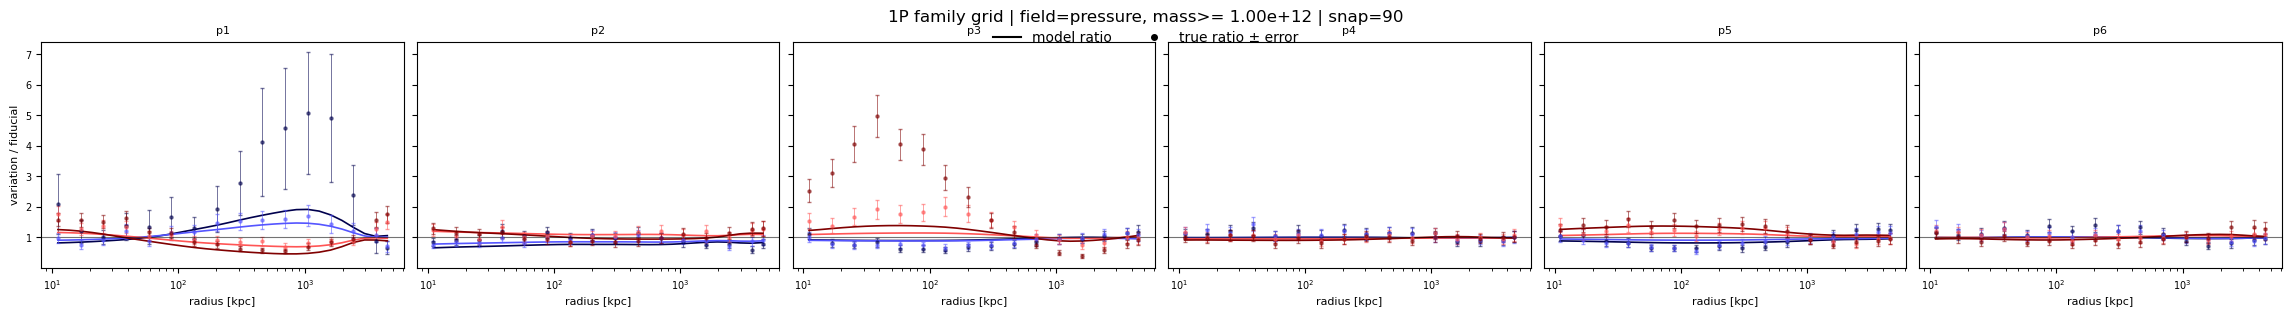

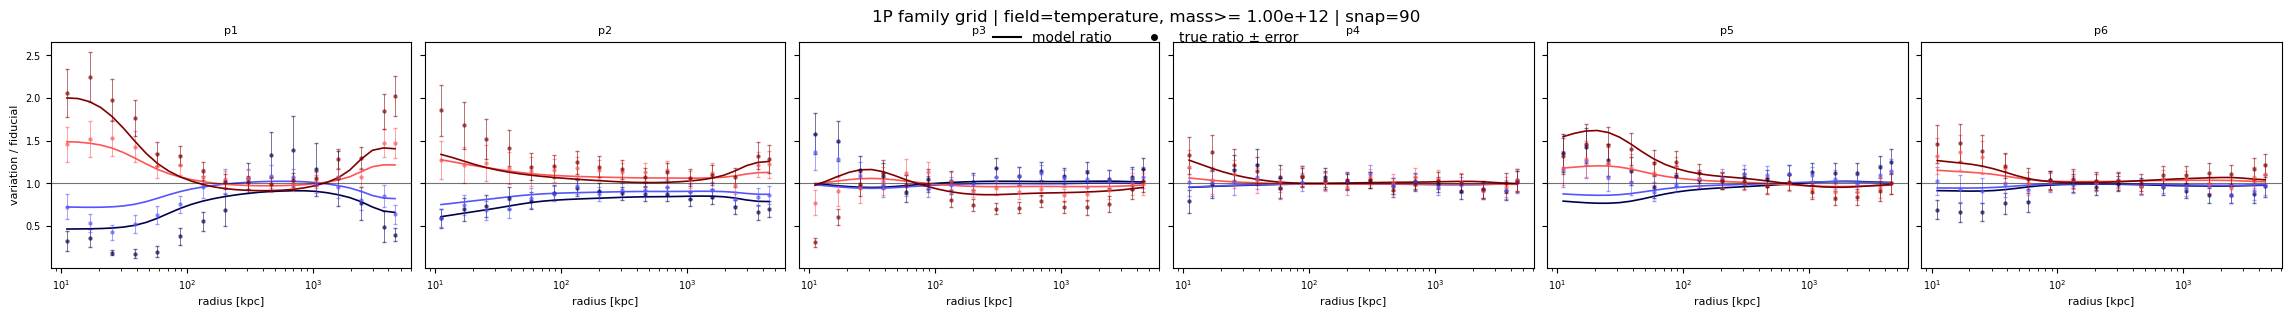

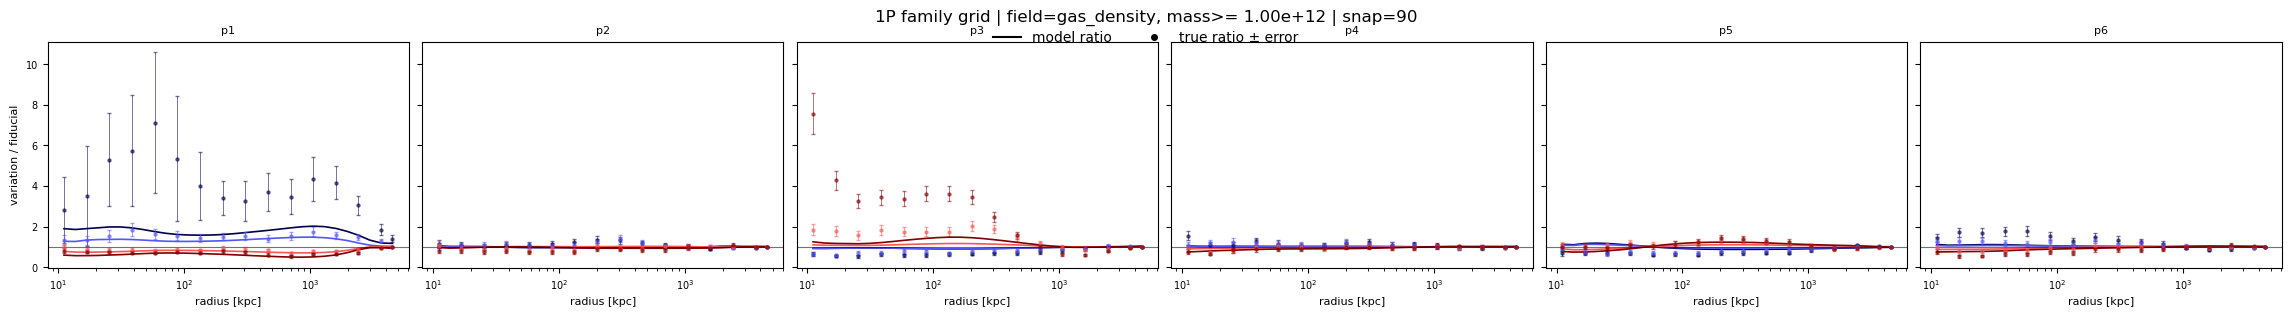

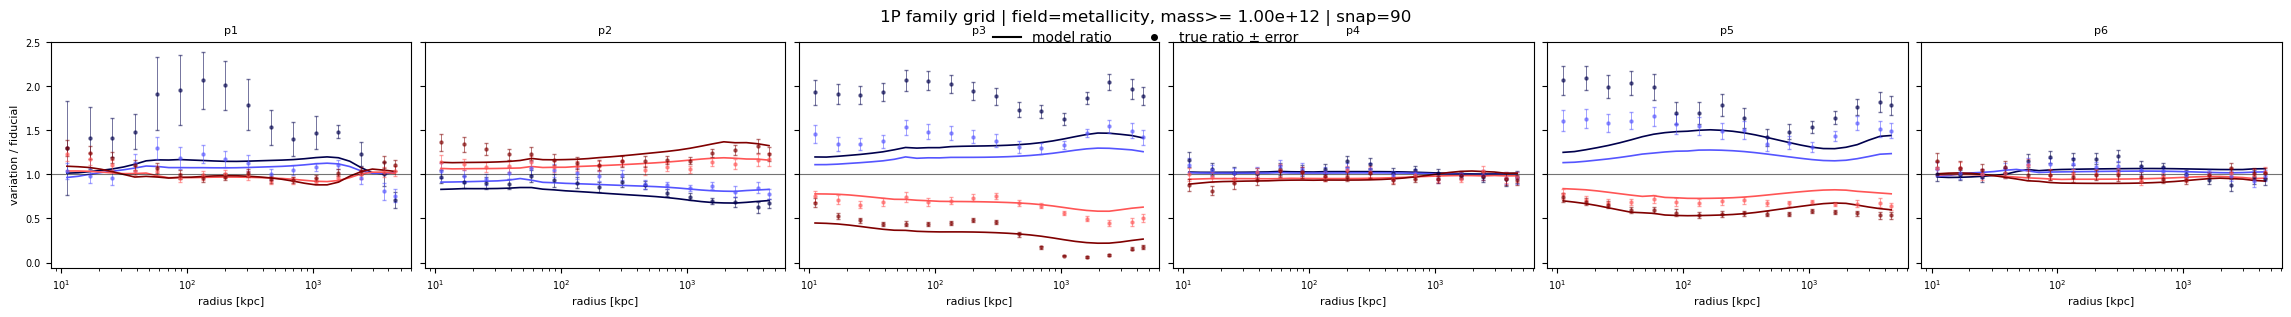

In [8]:
# Build cache for the single loaded snapshot and render family grids.
onep_cache, onep_summary_df, onep_skipped_tags = build_onep_cache_for_snap(
    snapnum=ONEP_SNAPNUM,
    fields=ONEP_REQUESTED_FIELDS,
    n_samples=ONEP_NSAMPLES,
)

print(f'Built cache for snapshot {ONEP_SNAPNUM}: {len(onep_cache)} tags')
print(f'Skipped tags: {len(onep_skipped_tags)}')
if len(onep_skipped_tags) > 0:
    print('First skipped tags:', onep_skipped_tags[:10])

display(onep_summary_df.head(12))

plot_onep_family_grid_test(onep_cache, field='pressure',    n_cols=6, max_rows=6, snapnum=ONEP_SNAPNUM)
plot_onep_family_grid_test(onep_cache, field='temperature', n_cols=6, max_rows=6, snapnum=ONEP_SNAPNUM)
plot_onep_family_grid_test(onep_cache, field='gas_density', n_cols=6, max_rows=6, snapnum=ONEP_SNAPNUM)
plot_onep_family_grid_test(onep_cache, field='metallicity', n_cols=6, max_rows=6, snapnum=ONEP_SNAPNUM)

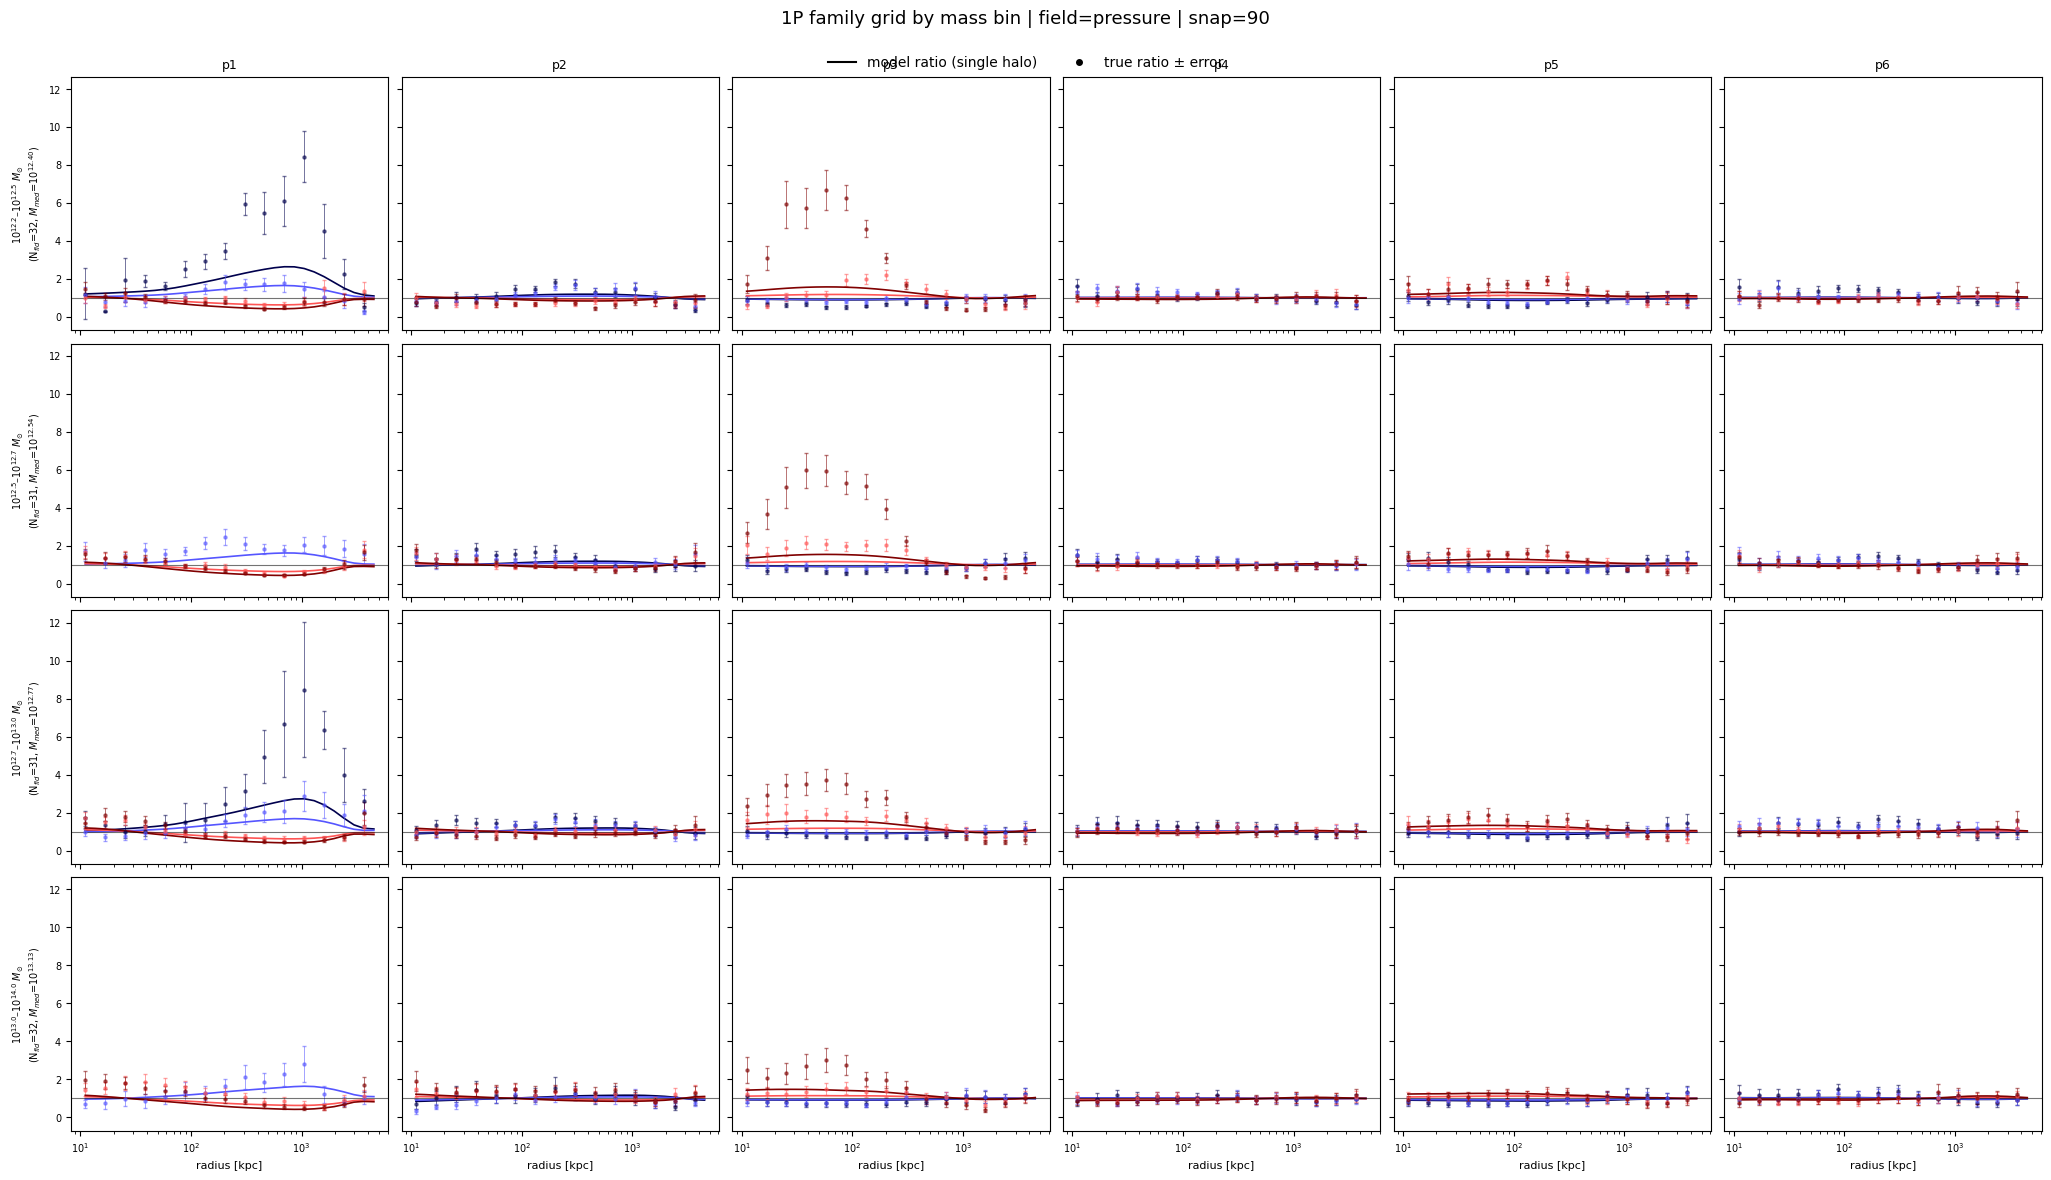

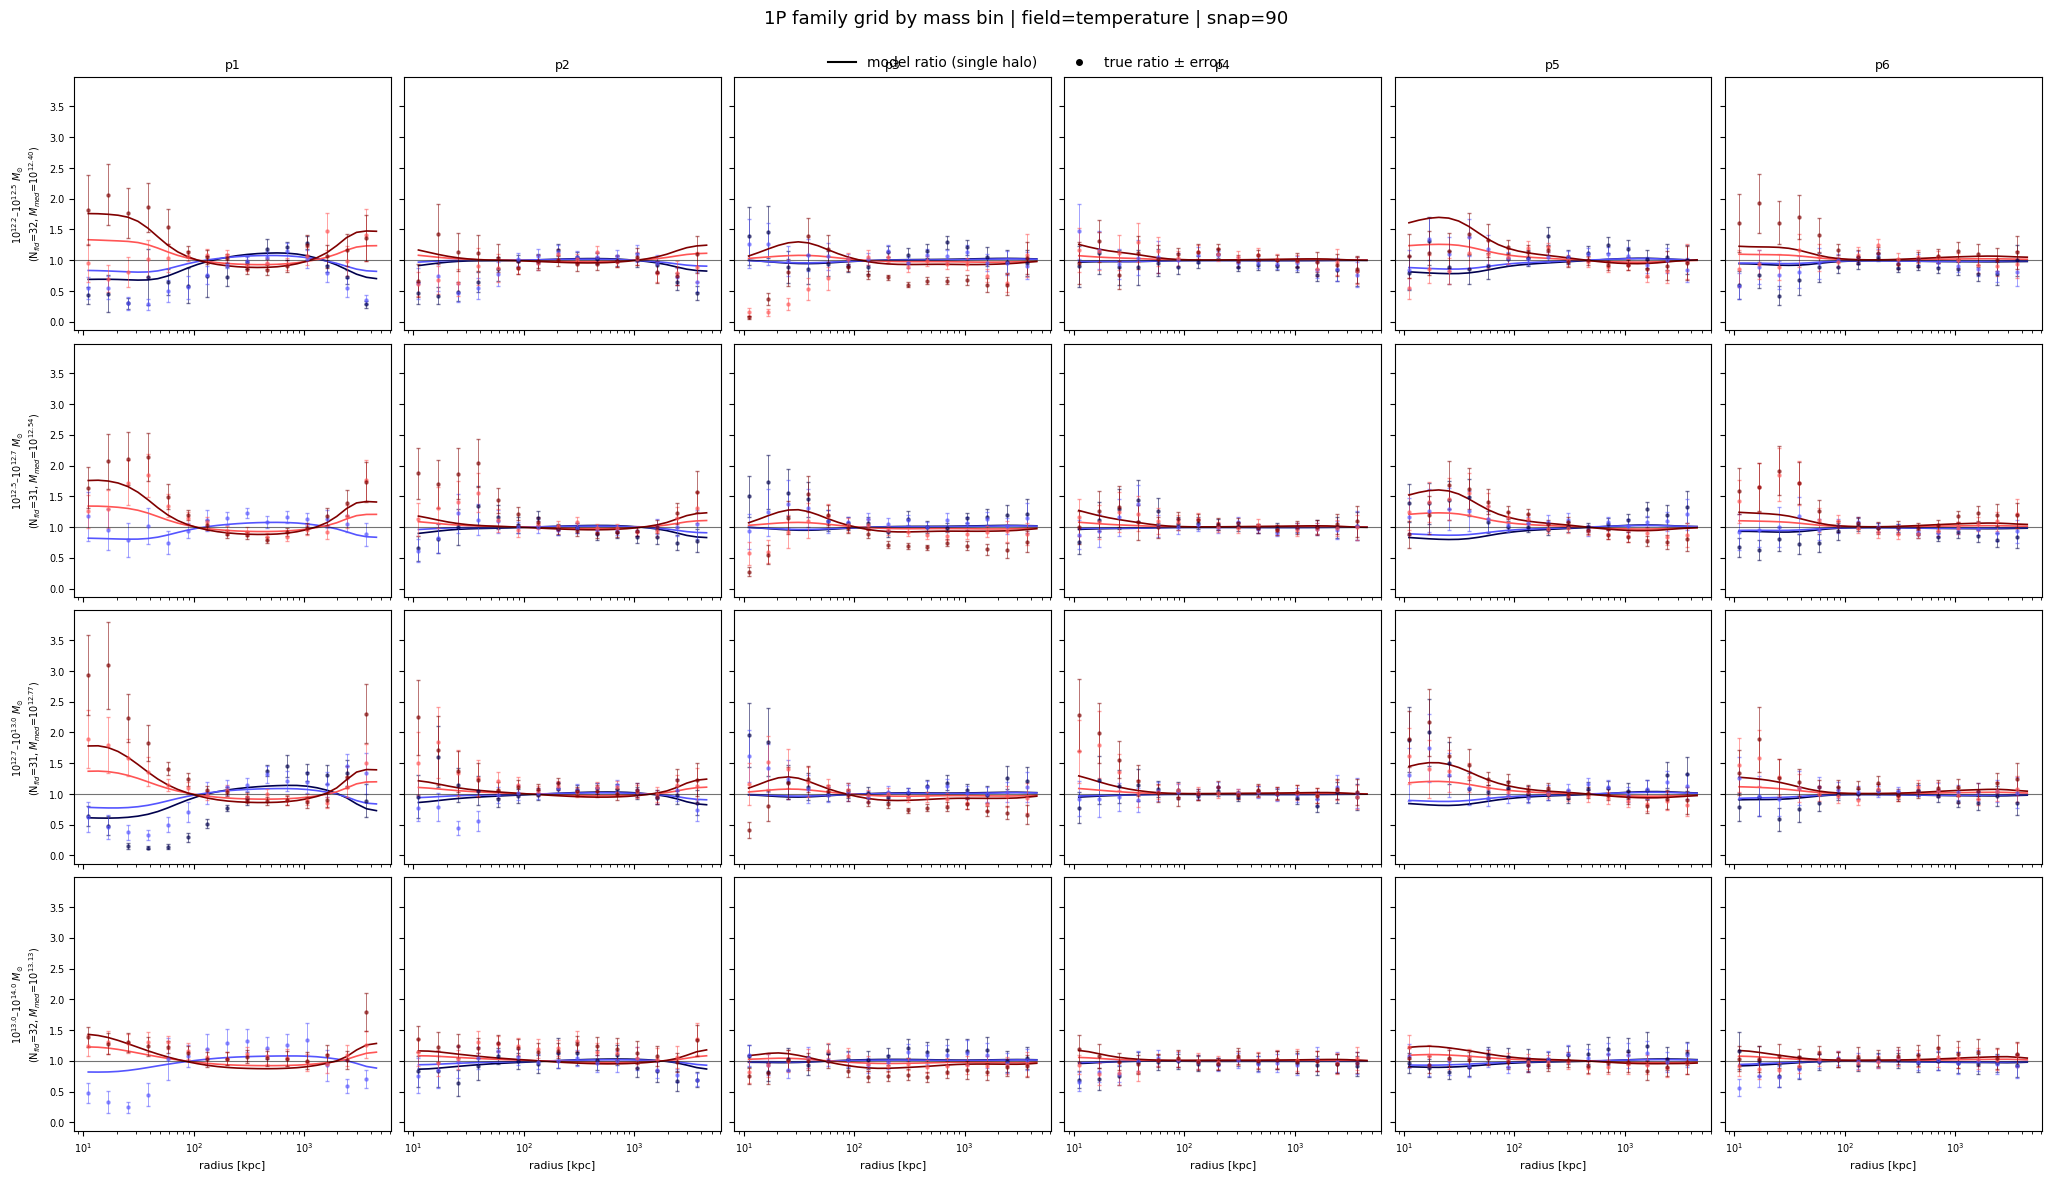

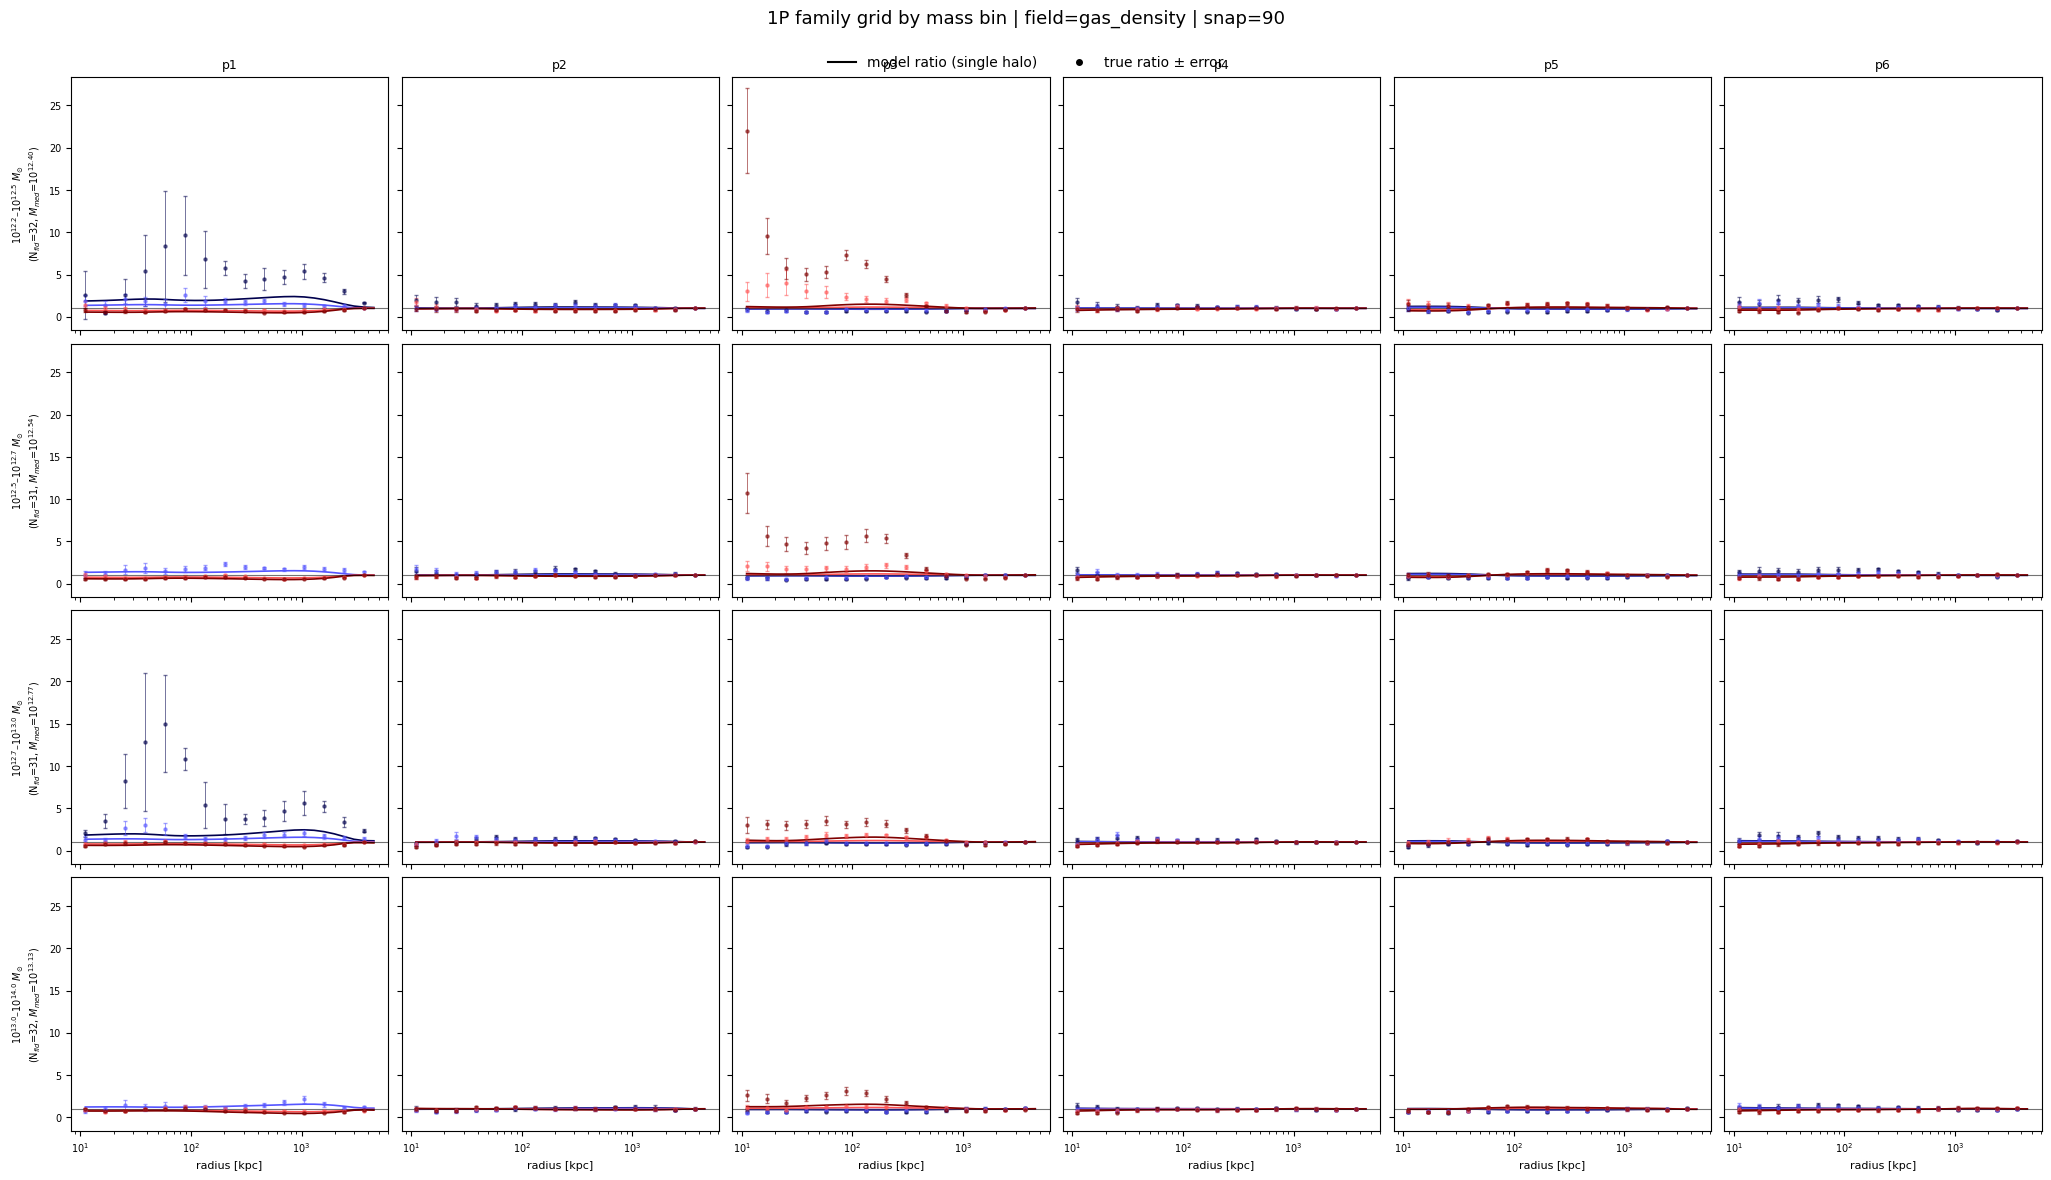

In [9]:
# 1P family-grid split by mass bins.
# For each field, produce a figure where rows = mass bins, columns = parameters.
# Each panel shows variation/fiducial ratio for truth (points) and prediction (lines).
# The emulator prediction is a SINGLE halo at the median M500c/R500c of each bin,
# ensuring we test parameter sensitivity at a fixed mass rather than averaging.

def plot_1p_family_grid_by_massbin(
    onep_cache,
    field='pressure',
    fiducial_tag='1P_p1_0',
    variation_suffixes=('n2', 'n1', '1', '2'),
    logm_start=12.0,
    n_mass_bins=4,
    min_count_per_bin=3,
    max_params=6,
    snapnum=None,
    eps=1e-30,
):
    import re

    snapnum = int(ONEP_SNAPNUM if snapnum is None else snapnum)
    cache = onep_cache

    if fiducial_tag not in cache:
        raise KeyError(f'Missing fiducial tag: {fiducial_tag}')

    # ---- Discover parameters in natural order ----
    pat = re.compile(r'^1P_(.+)_.+$')
    base_params = sorted({pat.match(t).group(1) for t in cache if pat.match(t)})
    base_params = _natural_base_param_order(base_params)[:max_params]
    n_params = len(base_params)
    if n_params == 0:
        print('No base parameters found.')
        return

    # ---- Build mass bins from fiducial tag ----
    fid = cache[fiducial_tag]
    fid_masses = np.asarray(fid['M500c'], dtype=np.float64)
    fid_r500c  = np.asarray(fid['R500c'], dtype=np.float64)
    fid_logm   = np.log10(np.clip(fid_masses, 1e-30, None))
    r_kpc      = np.asarray(fid['radial_bins'], dtype=np.float64)

    pool = fid_logm[fid_logm >= float(logm_start)]
    if pool.size < max(2, n_mass_bins):
        pool = fid_logm.copy()
    edges = np.unique(np.quantile(pool, np.linspace(0.0, 1.0, int(n_mass_bins) + 1)))
    if edges.size < int(n_mass_bins) + 1:
        lo_e = max(float(logm_start), float(np.nanmin(fid_logm)))
        hi_e = float(np.nanmax(fid_logm))
        edges = np.linspace(lo_e, hi_e if hi_e > lo_e else lo_e + 0.2, int(n_mass_bins) + 1)

    bin_info = []
    for i_bin in range(len(edges) - 1):
        lo_e, hi_e = edges[i_bin], edges[i_bin + 1]
        if i_bin < len(edges) - 2:
            sel = (fid_logm >= lo_e) & (fid_logm < hi_e)
        else:
            sel = (fid_logm >= lo_e) & (fid_logm <= hi_e)
        n_in = int(np.sum(sel))
        if n_in >= int(min_count_per_bin):
            bin_info.append({
                'lo': lo_e, 'hi': hi_e, 'n_fid': n_in,
                'med_mass': float(np.median(fid_masses[sel])),
                'med_r500': float(np.median(fid_r500c[sel])),
            })

    n_bins = len(bin_info)
    if n_bins == 0:
        print('No mass bins with enough fiducial halos.')
        return

    # ---- Helpers ----
    def _extract_field_single(pred_obj, field_name, halo_idx):
        """Extract predicted profile for a single halo from a multi-halo prediction."""
        names = list(pred_obj.field_names)
        if field_name not in names:
            return None
        j = names.index(field_name)
        mu = np.asarray(pred_obj.mean, dtype=np.float64)
        if mu.ndim == 3:
            return mu[halo_idx, :, j]
        if mu.ndim == 2 and len(names) == 1:
            return mu[halo_idx, :]
        return None

    def _bin_mask(logm_arr, lo, hi, is_last):
        if is_last:
            return (logm_arr >= lo) & (logm_arr <= hi)
        return (logm_arr >= lo) & (logm_arr < hi)

    def _median_and_err(arr_2d):
        arr_2d = np.asarray(arr_2d, dtype=np.float64)
        med = np.nanmedian(arr_2d, axis=0)
        n = np.sum(np.isfinite(arr_2d), axis=0).astype(np.float64)
        mad = np.nanmedian(np.abs(arr_2d - med[None, :]), axis=0)
        sigma_rob = 1.4826 * mad
        err = 1.2533 * sigma_rob / np.sqrt(np.maximum(n, 1.0))
        err[~np.isfinite(err)] = 0.0
        return med, err

    def _predict_single_halo_per_bin(theta, n_bins_local):
        """Run emulator for one halo per mass bin at the bin-median mass."""
        single_masses = np.array([b['med_mass'] for b in bin_info[:n_bins_local]], dtype=np.float32)
        single_r500  = np.array([b['med_r500'] for b in bin_info[:n_bins_local]], dtype=np.float64)
        single_rr500 = (r_kpc[None, :] / np.maximum(single_r500[:, None], 1e-12)).astype(np.float32)
        try:
            return emu.predict(
                theta=theta, M=single_masses, r_bins=single_rr500,
                field=[field], snapnum=snapnum, n_samples=ONEP_NSAMPLES,
            )
        except TypeError:
            return emu.predict(
                theta=theta, M=single_masses, r_bins=single_rr500,
                field=[field], n_samples=ONEP_NSAMPLES,
            )

    # ---- Predict single halo per bin for fiducial ----
    fid_pred = _predict_single_halo_per_bin(fid['theta'], n_bins)
    fid_pred_profiles = []  # one (n_r,) array per bin
    for i_bin in range(n_bins):
        fid_pred_profiles.append(_extract_field_single(fid_pred, field, i_bin))

    # ---- Predict single halo per bin for each variation tag; cache results ----
    # tag -> list of (n_r,) arrays, one per bin
    var_pred_cache = {}
    all_tags = set()
    for base in base_params:
        for sfx in variation_suffixes:
            tag = f'1P_{base}_{sfx}'
            if tag in cache and tag not in var_pred_cache:
                all_tags.add(tag)
    for tag in sorted(all_tags):
        rec = cache[tag]
        pred_tag = _predict_single_halo_per_bin(rec['theta'], n_bins)
        var_pred_cache[tag] = [
            _extract_field_single(pred_tag, field, i_bin)
            for i_bin in range(n_bins)
        ]

    # ---- Plot: rows = mass bins, columns = parameters ----
    colors = plt.cm.seismic(np.linspace(0, 1, len(variation_suffixes)))
    step = max(1, int(r_kpc.size // 12))
    idx = np.arange(0, r_kpc.size, step)

    fig, axes = plt.subplots(
        n_bins, n_params,
        figsize=(3.4 * n_params, 2.8 * n_bins),
        constrained_layout=True,
        sharex=True, sharey=True,
    )
    axes = np.atleast_2d(axes)
    if n_bins == 1:
        axes = axes.reshape(1, n_params)
    if n_params == 1:
        axes = axes.reshape(n_bins, 1)

    for i_bin, binfo in enumerate(bin_info):
        lo_e, hi_e = binfo['lo'], binfo['hi']
        is_last = (i_bin == n_bins - 1)

        # Fiducial: true median from all halos in bin; prediction = single halo.
        fid_true_all = np.asarray(fid['true_profiles'][field], dtype=np.float64)
        fid_mask = _bin_mask(fid_logm, lo_e, hi_e, is_last)
        true_fid_med, true_fid_err = _median_and_err(np.clip(fid_true_all[fid_mask], eps, None))
        pred_fid_i = fid_pred_profiles[i_bin]  # single-halo prediction (n_r,)

        if pred_fid_i is None:
            for j_p in range(n_params):
                axes[i_bin, j_p].text(0.5, 0.5, 'no fid pred', ha='center',
                                       va='center', transform=axes[i_bin, j_p].transAxes, fontsize=7)
            continue

        for j_p, base in enumerate(base_params):
            ax = axes[i_bin, j_p]
            ax.set_xscale('log')

            if i_bin == 0:
                ax.set_title(base, fontsize=9)
            if i_bin == n_bins - 1:
                ax.set_xlabel('radius [kpc]', fontsize=8)
            if j_p == 0:
                ax.set_ylabel(
                    rf'$10^{{{lo_e:.1f}}}$–$10^{{{hi_e:.1f}}}$ $M_{{\odot}}$'
                    f'\n(N$_{{fid}}$={binfo["n_fid"]}, '
                    rf'$M_{{med}}$=10$^{{{np.log10(binfo["med_mass"]):.2f}}}$)',
                    fontsize=7,
                )
            ax.tick_params(labelsize=7)

            for sfx, color in zip(variation_suffixes, colors):
                tag = f'1P_{base}_{sfx}'
                rec = cache.get(tag, None)
                if rec is None:
                    continue

                # True: median of variation halos in this mass bin.
                m_var = np.asarray(rec['M500c'], dtype=np.float64)
                logm_var = np.log10(np.clip(m_var, 1e-30, None))
                var_mask = _bin_mask(logm_var, lo_e, hi_e, is_last)
                if int(np.sum(var_mask)) < int(min_count_per_bin):
                    continue

                true_var_all = np.asarray(rec['true_profiles'][field], dtype=np.float64)
                true_var_med, true_var_err = _median_and_err(np.clip(true_var_all[var_mask], eps, None))

                # Prediction: single halo at bin-median mass.
                pred_var_i = var_pred_cache.get(tag, [None] * n_bins)[i_bin]
                if pred_var_i is None:
                    continue

                ratio_true = true_var_med / np.clip(true_fid_med, eps, None)
                ratio_pred = pred_var_i / np.clip(pred_fid_i, eps, None)

                # Propagate uncertainty on the true ratio.
                frac_var = true_var_err / np.clip(np.abs(true_var_med), eps, None)
                frac_fid = true_fid_err / np.clip(np.abs(true_fid_med), eps, None)
                ratio_err = np.abs(ratio_true) * np.sqrt(frac_var ** 2 + frac_fid ** 2)

                ax.plot(r_kpc, ratio_pred, color=color, lw=1.2)
                ax.errorbar(
                    r_kpc[idx], ratio_true[idx], yerr=ratio_err[idx],
                    fmt='o', ms=2.2, lw=0.7, elinewidth=0.7, capsize=1.6,
                    color=color, alpha=0.55,
                )

            ax.axhline(1.0, color='k', lw=0.8, alpha=0.55)

    legend_handles = [
        plt.Line2D([0], [0], color='k', lw=1.5, label='model ratio (single halo)'),
        plt.Line2D([0], [0], color='k', marker='o', linestyle='None', markersize=4,
                   label='true ratio ± error'),
    ]
    fig.legend(handles=legend_handles, loc='upper center', ncol=2,
               frameon=False, bbox_to_anchor=(0.5, 1.01))
    fig.suptitle(
        f'1P family grid by mass bin | field={field} | snap={snapnum}',
        y=1.04, fontsize=13,
    )
    plt.show()


for fld in ('pressure', 'temperature', 'gas_density'):
    plot_1p_family_grid_by_massbin(
        onep_cache, field=fld,
        n_mass_bins=4, max_params=6,
    )
